### **Question** put N particles in L boxes

In [94]:
import numpy as np
from numpy import linalg as la
from scipy import linalg as la2
import math
import scipy as sp
from matplotlib import pyplot as plt

In [85]:
def one_in_first(l):

    """
    For all distributions in 1, add one atom in the first trap.
    """ 
    L = len(l[0])
    return [list(np.array([1]+[0]*(L-1)) + np.array(e)) for e in l]

def zero_in_first(l) :

    """
    For all distributions in l, add a new empty trap.
    """
    return [[0]+ e for e in l]


def distribute(N, L):

    '''
    Distributes N indistiguishable atoms in L traps.
    Returns a list of the possible distributions.
    (A distribution is itself a list of L non-negative integers whith sum N.)
    '''

    if N == 0:
        return [[0,]*L]
    elif L == 1 :
        return [[N]]
    else:
        return one_in_first(distribute(N-1, L)) + zero_in_first(distribute(N, L- 1) )



# for e in distribute (5, 5):
#  print(e)

### Express the question as a function of: N-1 p in L boxes and N p in L-1 boxes 

In [89]:
def roundloop(k,L):
    """
    adjusts k to stay within the bounds of 0 to L-1 using modular arithmetic
    """
    if k >= L:
        return k%L
    elif k<0:
        return (L+k)%L
    else:
        return k

def lefthop(k,L):
    """
    Return an array of dimension L, with -1 at position k, and +1 at position k-1 
    """
    tab=np.zeros(L)
    tab[k] = -1
    tab[roundloop(k-1,L)] = +1
    return tab


def righthop(k,L):
    """
    Return an array of dimension L, with -1 at position k, and +1 at position k+1 
    """
    tab=np.zeros(L)
    tab[k] = -1
    tab[roundloop(k+1,L)] = +1
    return tab

#print(lefthop(0,2))

#print ("roundloop test ",roundloop(18, 8))


# Find the position of a column in a 2D array
def find_list_pos(arraylist, testlist):
    """
    return the index k of an arraylist for which arraylist[k]==testlist
    """
    for k in range(len(arraylist)):
        if np.all(arraylist[k]==testlist):
            return k 
            #break


# Generate Hamiltonian matrix
def Hamiltonian(U, J, N):
    """
    Return the expression of the hamiltonian matrix, 
    calculated on the basis generated
    """
    # H = U/2 Sum over i of n_i*(n_i - 1) - J *Sum over i,j of a_i^{dagger}*a_j  
    
    # Initialize the Hamiltonian matrix with zeros
    dimension = int(sp.special.comb(N+N-1,N)) # dimension

    #print("the dimension is", dimension)
    H = np.zeros((dimension, dimension), dtype=complex)
    #print(np.shape(H))
    # generate the basis 
    basis = np.array(distribute(N,N))
    #print(basis)
    #print(np.shape(basis))
    # Hamiltonian calculation

    for i in range(dimension):
        H[i,i] += U*0.5*sum(basis[i]*(basis[i]-1))

        for j in range(N):    # hopping atoms
            if basis[i,j] > 0:
                #print("the",i,j,"element is ",basis[i,j])
                #print(basis[i])
                left = basis[i] + lefthop(j,N)   # hop to the left
                #print(left)
                right = basis[i] + righthop(j,N)  # hop  to the right
                #print(right)

                left_pos = find_list_pos(basis, left)
                #print(left_pos)
                right_pos = find_list_pos(basis, right)
                #print(right_pos)
                #print("index", roundloop(j-1,N)+1)
                H[i, left_pos] += -J*math.sqrt(basis[i,j])*math.sqrt(basis[i, roundloop(j-1,N)]+1)
                H[i, right_pos] += -J*math.sqrt(basis[i,j])*math.sqrt(basis[i, roundloop(j+1,N)]+1)

    return H
print(Hamiltonian(1, 10, 3))


[[  3.        +0.j -17.32050808+0.j -17.32050808+0.j   0.        +0.j
    0.        +0.j   0.        +0.j   0.        +0.j   0.        +0.j
    0.        +0.j   0.        +0.j]
 [-17.32050808+0.j   1.        +0.j -10.        +0.j -20.        +0.j
  -14.14213562+0.j   0.        +0.j   0.        +0.j   0.        +0.j
    0.        +0.j   0.        +0.j]
 [-17.32050808+0.j -10.        +0.j   1.        +0.j   0.        +0.j
  -14.14213562+0.j -20.        +0.j   0.        +0.j   0.        +0.j
    0.        +0.j   0.        +0.j]
 [  0.        +0.j -20.        +0.j   0.        +0.j   1.        +0.j
  -14.14213562+0.j   0.        +0.j -17.32050808+0.j -10.        +0.j
    0.        +0.j   0.        +0.j]
 [  0.        +0.j -14.14213562+0.j -14.14213562+0.j -14.14213562+0.j
    0.        +0.j -14.14213562+0.j   0.        +0.j -14.14213562+0.j
  -14.14213562+0.j   0.        +0.j]
 [  0.        +0.j   0.        +0.j -20.        +0.j   0.        +0.j
  -14.14213562+0.j   1.        +0.j   0.     

In [160]:
def annihilation(index, state):

    """
     Annihilation operator for a particular basis on a particular index.
    """

    if index < 0 or index >= len(state):
        raise ValueError("Invalid index for annihilation operator.")
    
    else:
        new_state = state.copy()
        if new_state[index] == 0: # no annihilation
            return new_state
        else:
            new_state[index] -= 1 
            return new_state    

#test annihiation
# Example of using droppart
index_to_annihilate = 1

# state 
state = [0,1,0,0,1]
print(f"Original state: {state}")
# Applying the annihilation operator at position j=1
resulting_state = annihilation(index_to_annihilate, state)
print("testing annihilation")
print(f"Original state: {state}")
print(f"After annihilation at position {index_to_annihilate}: {resulting_state}")


def calculate_denistymat(phi0, N, basis):
    dimension = len(phi0)
    density_matrix = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            c = np.zeros((dimension, dimension))
            for k in range(dimension):
                for l in range(dimension):
                    #print(basis[k])
                    if annihilation(j,basis[k]) == annihilation(i,basis[l]):
                        c[k, l] = phi0[k] * phi0[l] * np.sqrt(basis[k, j] * basis[l, i])
                        #print("here")
                    else:
                        c[k, l] = 0
            density_matrix[i, j] = np.sum(c)
    return density_matrix


def fluctuation(phi0, basis):
    
    dimension = len(phi0)
    sqrd_expct, expct = np.zeros(dimension), np.zeros(dimension) 

    for k in range(dimension):
        sqrd_expct[k] = phi0[k] * phi0[k] * basis[k, 0] * basis[k, 0]
        expct[k] = phi0[k] * phi0[k] * basis[k, 0]

    fluc = np.sum(sqrd_expct) - np.sum(expct)**2
    return fluc

Original state: [0, 1, 0, 0, 1]
testing annihilation
Original state: [0, 1, 0, 0, 1]
After annihilation at position 1: [0, 0, 0, 0, 1]


3
the basis is: [[3 0 0]
 [2 1 0]
 [2 0 1]
 [1 2 0]
 [1 1 1]
 [1 0 2]
 [0 3 0]
 [0 2 1]
 [0 1 2]
 [0 0 3]]
ground state:
 [0.1861699 0.333263  0.333263  0.333263  0.4792045 0.333263  0.1861699
 0.333263  0.333263  0.1861699]
density matrix:
 [[1.        0.9998208 0.9998208]
 [0.9998208 1.        0.9998208]
 [0.9998208 0.9998208 1.       ]]
fluctuation:
 0.652212298748984


Text(0, 0.5, 'fluctuation')

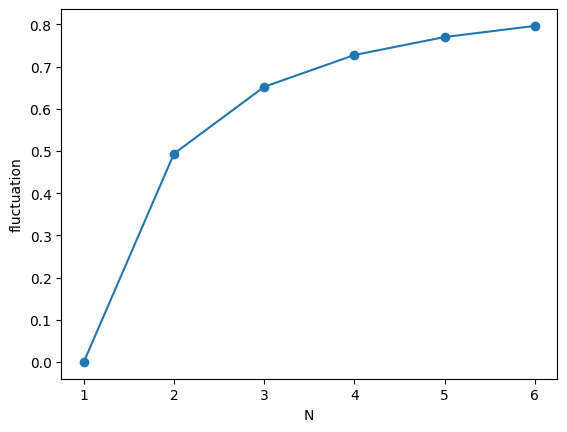

In [167]:
N=3
print(N)
H = Hamiltonian(1, 10, N)
phi0 = np.real(la.eig(H)[1][:,0])

basis = np.array(distribute(N,N))

print("the basis is:",basis)

print("ground state:\n",phi0)


densitymat = calculate_denistymat(phi0, N, basis)

print("density matrix:\n",densitymat)

dfluc = fluctuation(phi0, basis)

print("fluctuation:\n", dfluc)

def compute_fluc(N):
    H = Hamiltonian(1,10,N)
    basis = np.array(distribute(N,N))
    phi0 = np.real(la.eig(H)[1][:,0])
    densitymat = calculate_denistymat(phi0, N, basis)
    dfluc = fluctuation(phi0, basis)
    return dfluc
fluc = []
N = np.array(range(1,7))
#print(N)
for n in N:
    fluc.append(compute_fluc(n))
plt.plot(N, fluc,'o-')
plt.xlabel("N")
plt.ylabel("fluctuation")

